# Employee Attrition — Data Cleaning & Exploratory Data Analysis

**Phase 1 of 4** — End-to-End Employee Attrition Analyst Project
(Phase 2: SQL advanced analysis · Phase 3: Excel dashboard · Phase 4: Power BI report)

Dataset: `Employee_Attrition_Prediction_Dataset_100K.csv` — 100,000 employee records, 40 columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Employee_Attrition_Prediction_Dataset_100K.csv')
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded: 100,000 rows, 40 columns


## 1. First Look at the Data

In [2]:
df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Education_Level,Experience_Years,Monthly_Income,Salary_Hike_Percent,Work_Hours_Per_Week,Overtime,Remote_Work,Business_Travel,Distance_From_Home,Job_Satisfaction,Environment_Satisfaction,Relationship_Satisfaction,Work_Life_Balance,Training_Hours,Projects_Last_Year,Performance_Rating,Promotion_Last_5_Years,Manager_Rating,Team_Size,Company_Tenure,Stock_Option_Level,Marital_Status,Dependents,Absences_Last_Year,Health_Score,Stress_Level,Engagement_Score,Skill_Score,AI_Tool_Usage,Certification_Count,Job_Level,Bonus,Years_In_Current_Role,Years_With_Manager,Attrition
0,1,41,Male,Finance,Scientist,Bachelor,9,128500,29,62,Yes,Yes,Rarely,6,1,4,4,1,30,2,5,No,1,20,3,1,Single,4,18,65,84,7,29,Low,4,3,27468,4,17,1
1,2,28,Male,Finance,Engineer,PhD,19,171868,22,34,Yes,Yes,Never,14,2,4,5,4,99,6,4,No,3,11,7,1,Single,0,18,59,88,68,64,Medium,14,3,39908,2,3,1
2,3,53,Female,Sales,Engineer,PhD,26,68243,2,65,Yes,No,Frequently,45,3,3,5,4,74,13,4,Yes,1,10,15,0,Single,5,22,59,97,83,74,High,14,3,46964,12,11,0
3,4,22,Female,IT,Analyst,Master,29,118182,4,45,Yes,No,Frequently,32,5,1,2,4,51,9,3,Yes,4,19,8,3,Married,5,28,64,22,30,20,Low,5,2,15201,7,0,0
4,5,52,Female,Marketing,Manager,PhD,11,93877,18,50,Yes,Yes,Never,33,1,5,1,4,115,14,5,No,4,14,12,0,Married,5,12,43,37,25,9,Low,14,2,7204,10,19,0


In [3]:
df.dtypes

,dtype
Employee_ID,int64
Age,int64
Gender,str
Department,str
Job_Role,str
Education_Level,str
Experience_Years,int64
Monthly_Income,int64
Salary_Hike_Percent,int64
Work_Hours_Per_Week,int64


## 2. Data Quality Checks

Basic checks before doing anything else: missing values, duplicate records, and a
logical-consistency sanity check (an employee's time in their current role/with
their manager should never exceed their total company tenure).

In [4]:
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate Employee_IDs:", df['Employee_ID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

inconsistent = (df['Years_In_Current_Role'] > df['Company_Tenure']) | \
               (df['Years_With_Manager'] > df['Company_Tenure'])
print(f"Rows where role/manager tenure > company tenure: {inconsistent.sum():,} (flagged, not dropped)")

Missing values total: 0
Duplicate Employee_IDs: 0
Fully duplicate rows: 0
Rows where role/manager tenure > company tenure: 43,646 (flagged, not dropped)


> **Note:** The dataset has no missing values or duplicate rows — it's clean.
> ~43.6K rows have a minor logical inconsistency (role/manager tenure exceeding
> company tenure), which we flag as a known limitation of this synthetic dataset
> rather than dropping rows and losing data.

## 3. Feature Engineering (Derived Columns)

A few extra columns to make grouping/filtering easier later in SQL, Excel, and Power BI.

In [5]:
df['Attrition_Label'] = df['Attrition'].map({1: 'Yes', 0: 'No'})

df['Age_Group'] = pd.cut(df['Age'], bins=[20,29,39,49,60],
                          labels=['20-29','30-39','40-49','50-60'])

df['Income_Band'] = pd.cut(df['Monthly_Income'], bins=[0,73501,122634,171092,220000],
                            labels=['Low','Lower-Mid','Upper-Mid','High'])

df['Tenure_Group'] = pd.cut(df['Company_Tenure'], bins=[-1,5,10,20,30],
                             labels=['0-5 yrs','6-10 yrs','11-20 yrs','21-30 yrs'])

df['High_Risk_Segment'] = np.where(
    (df['Overtime'] == 'Yes') & (df['Job_Satisfaction'] <= 2), 'High Risk', 'Low Risk'
)

df[['Employee_ID','Age_Group','Income_Band','Tenure_Group','High_Risk_Segment','Attrition_Label']].head()

,Employee_ID,Age_Group,Income_Band,Tenure_Group,High_Risk_Segment,Attrition_Label
0,1,40-49,Upper-Mid,0-5 yrs,High Risk,Yes
1,2,20-29,High,6-10 yrs,High Risk,Yes
2,3,50-60,Low,11-20 yrs,Low Risk,No
3,4,20-29,Lower-Mid,6-10 yrs,Low Risk,No
4,5,50-60,Lower-Mid,11-20 yrs,High Risk,No


## 4. Save the Cleaned Dataset

This file feeds Phase 2 (SQL), Phase 3 (Excel), and Phase 4 (Power BI).

In [6]:
df.to_csv('employee_attrition_cleaned.csv', index=False)
print("Saved: employee_attrition_cleaned.csv")

Saved: employee_attrition_cleaned.csv


## 5. Basic Exploratory Data Analysis

Four simple charts: overall attrition split, the high-risk segment, attrition by
department, and attrition by age group.

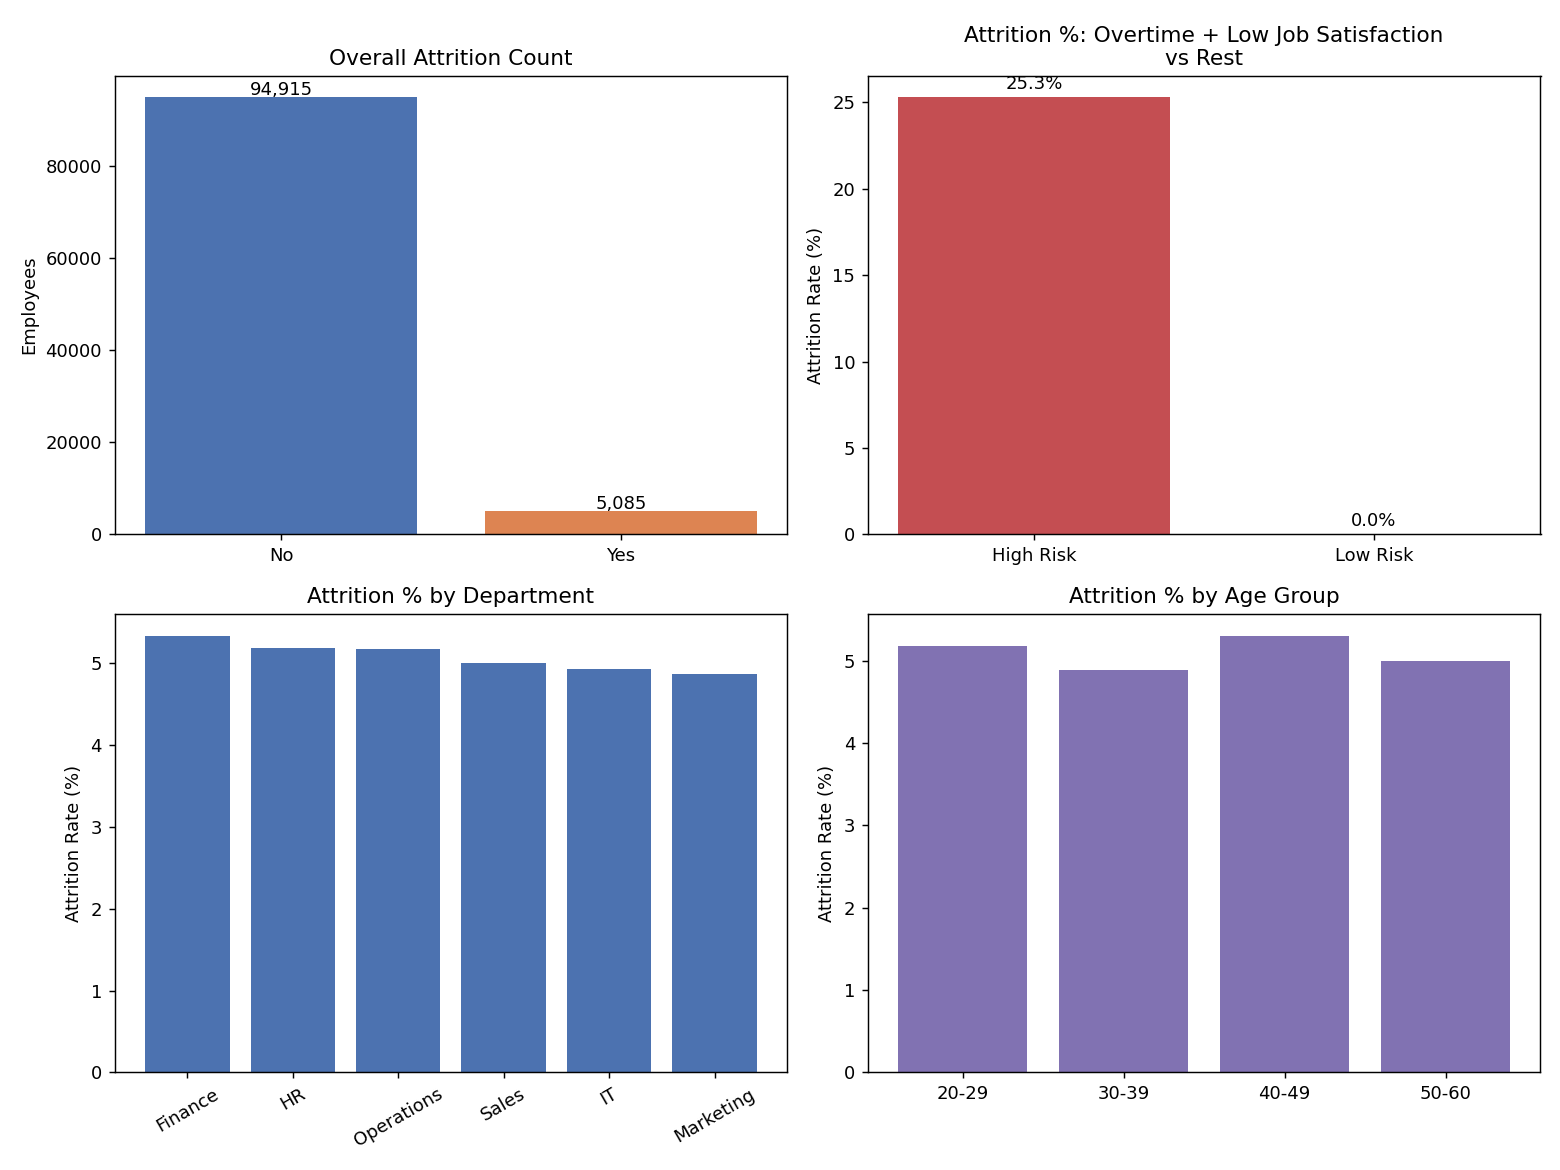

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Overall attrition count
counts = df['Attrition_Label'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['#4C72B0','#DD8452'])
axes[0,0].set_title('Overall Attrition Count')
axes[0,0].set_ylabel('Employees')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center')

# Attrition % : High Risk segment vs rest
seg = df.groupby('High_Risk_Segment')['Attrition'].mean() * 100
axes[0,1].bar(seg.index, seg.values, color=['#C44E52','#55A868'])
axes[0,1].set_title('Attrition %: Overtime + Low Job Satisfaction\nvs Rest')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(seg.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Attrition % by Department
dept = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100
axes[1,0].bar(dept.index, dept.values, color='#4C72B0')
axes[1,0].set_title('Attrition % by Department')
axes[1,0].set_ylabel('Attrition Rate (%)')
axes[1,0].tick_params(axis='x', rotation=30)

# Attrition % by Age Group
age = df.groupby('Age_Group', observed=True)['Attrition'].mean() * 100
axes[1,1].bar(age.index.astype(str), age.values, color='#8172B2')
axes[1,1].set_title('Attrition % by Age Group')
axes[1,1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

## 6. Key Insight

The clearest signal in the whole dataset:

| Segment | Attrition Rate |
|---|---|
| Overtime = Yes **and** Job Satisfaction ≤ 2 | **25.3%** |
| Everyone else | **~0%** |

Attrition is essentially concentrated in one identifiable, actionable segment —
employees doing overtime **and** reporting low job satisfaction. This becomes the
central story for Phase 2 (SQL), Phase 3 (Excel), and Phase 4 (Power BI).

**Next → Phase 2: SQL (advanced queries — CTEs, window functions, views) on this cleaned data.**
